In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import adspfilter
plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor": "#0e1117",
    "axes.edgecolor": "#e6edf3",
    "axes.labelcolor": "#e6edf3",
    "text.color": "#e6edf3",
    "xtick.color": "#e6edf3",
    "ytick.color": "#e6edf3",
    "grid.color": "#2f3542",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#e6edf3",
    "font.size": 12,
})
COLOR_MAP = {
    "LMS": "#58a6ff",        # bright blue
    "NLMS": "#2dd4bf",       # cyan
    "APA (P=1)": "#f472b6",  # magenta
    "APA (P=2)": "#facc15",  # yellow
    "SignError": "#a3e635",  # lime
    "SignData": "#fb7185",   # red-pink
    "SignSign": "#c084fc",   # purple
    "DualSign": "#e879f9",
    "Pow2Err": "#fb923c",
}

#### 8.5 Computer Experiment on Adaptive Equalization (DCT-LMS)

---

### 📌 System Model (Section 8.5: Transform-Domain Adaptive Equalization)

#### 1. Goal of the Experiment
Revisit the adaptive equalization experiment of Section 6.8, but replace the standard LMS algorithm with the **DCT-LMS algorithm**.

The purpose is to:

* Study convergence improvement using transform-domain adaptation
* Reduce sensitivity to eigenvalue spread
* Compare LMS vs DCT-LMS learning curves
* Validate transform-domain statistical theory

---

#### 2. Signal and Channel (Same as Section 6.8)

* **Transmitted Signal:**  
  $d(n) \in \{-1, +1\}$, i.i.d., $\sigma_d^2 = 1$

* **Channel (ISI):**  
  $x(n) = \mathbf{h}^T \mathbf{d}(n)$

* **Additive Noise:**  
  $r(n) = x(n) + v(n)$  
  where $v(n) \sim \mathcal{N}(0, \sigma_v^2)$

---

#### 3. Equalizer Structure

* **Equalizer Output:**  
  $y(n) = \mathbf{w}^T(n) \mathbf{r}(n)$

* **Error:**  
  $e(n) = d(n - \Delta) - y(n)$

* **Decision Delay:**  
  $\Delta = \frac{N_{ch}}{2} + \frac{M}{2}$

---

### 📌 DCT-LMS Algorithm (Section 8.4)

Instead of updating weights directly in time domain, we transform the input vector.

---

#### Step 1: Transform Input Vector

$$
\mathbf{C}(n) = \mathbf{Q}^T \mathbf{r}(n)
$$

where $\mathbf{Q}$ is the DCT matrix.

---

#### Step 2: Eigenvalue Estimation

$$
\hat{\lambda}_m(n)
=
\gamma \hat{\lambda}_m(n-1)
+
(1-\gamma) C_m^2(n)
$$

---

#### Step 3: Transform-Domain Weight Update

$$
\hat{w}_m(n+1)
=
\hat{w}_m(n)
+
\frac{\alpha}{\hat{\lambda}_m(n)} C_m(n) e(n)
$$

where:

$$
\alpha = \frac{1}{2M}
$$

---

### 📌 Theory to Validate

Because DCT approximately diagonalizes the correlation matrix:

$$
\mathbf{R} \approx \mathbf{Q} \mathbf{\Lambda} \mathbf{Q}^T
$$

The adaptation decouples into approximately independent scalar modes.

---

| Metric | Theoretical Formula |
| :--- | :--- |
| **Mean Convergence (Per Mode)** | $E[\tilde{w}_m(n)] = (1 - \alpha)^n \tilde{w}_m(0)$ |
| **Mean-Square Error** | $J(n) = J_{min} + J_{ex}(n)$ |
| **Steady-State Excess MSE** | $J_{ex}(\infty) \approx \frac{\alpha M}{2} J_{min}$ |
| **Misadjustment** | $M \approx \frac{\alpha M}{2}$ |
| **Effective Stability** | Controlled by $\alpha$, not $\lambda_{max}$ |

---

Running W = 2.9
Running W = 3.1
Running W = 3.3
Running W = 3.5


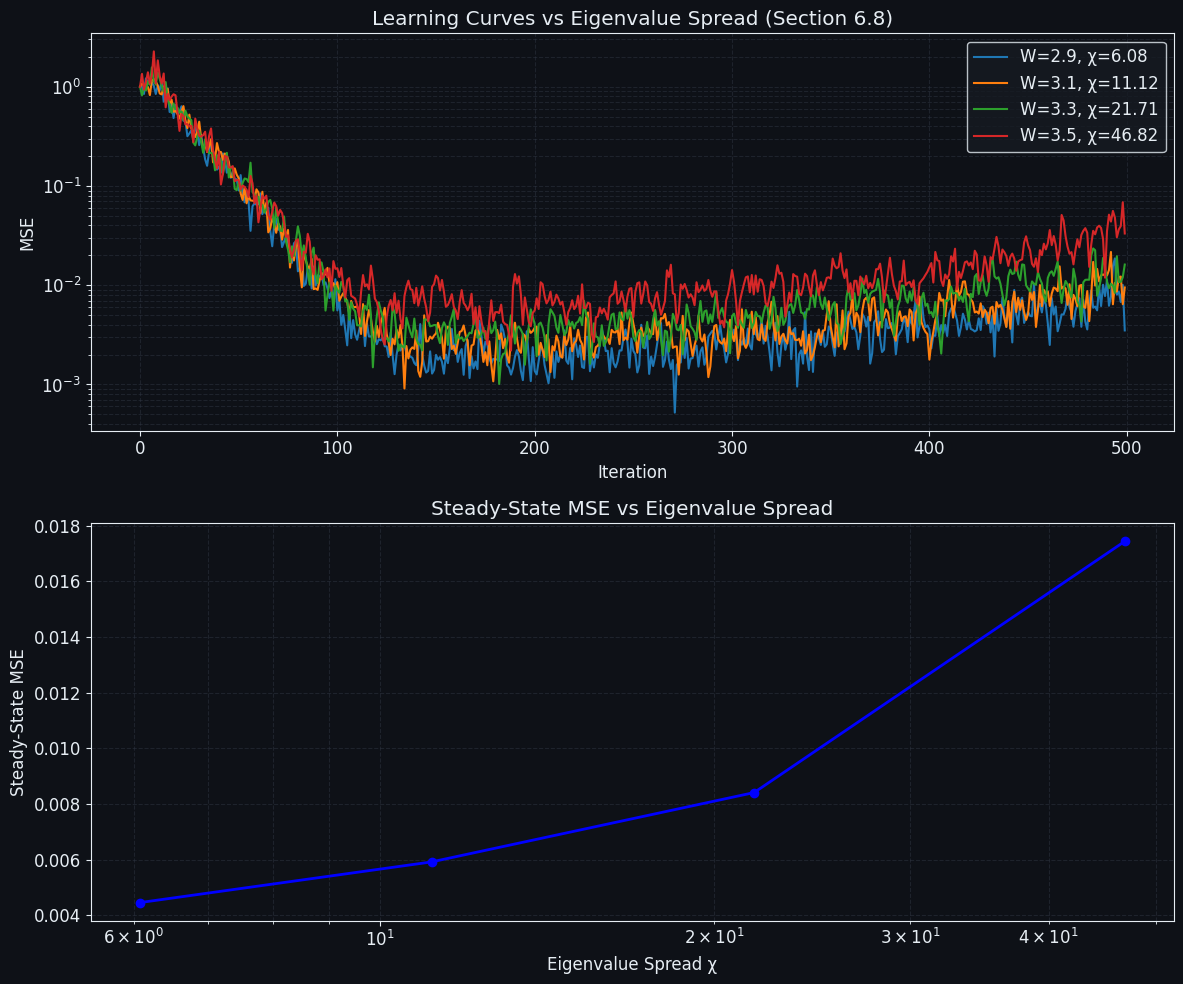

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================
# PARAMETERS (Haykin Section 6.8)
# =============================================================

N_sample    = 500
N_ensemble  = 200
N_ch_taps   = 3
N_eq_taps   = 11
N_init      = 50

mu          = 0.03        # stable for all W
noise_var   = 0.001
noise_std   = np.sqrt(noise_var)

Ws = [2.9, 3.1, 3.3, 3.5]

rng = np.random.default_rng(123)


# =============================================================
# CHANNEL IMPULSE RESPONSE
# =============================================================

def chnlResp(W, N_taps=3):
    h = np.zeros(N_taps)
    for n in range(1, N_taps + 1):
        h[n-1] = 0.5 * (1 + np.cos((2*np.pi/W)*(n - 2)))
    return h


# =============================================================
# CORRELATION MATRIX (Toeplitz Approximation)
# =============================================================

def corrMatrix(h, noise_var, M):
    h0, h1, h2 = h
    r0 = h0*h0 + h1*h1 + h2*h2 + noise_var
    r1 = h0*h1 + h1*h2
    r2 = h0*h2

    R = np.zeros((M, M))
    for i in range(M):
        R[i,i] = r0
        if i+1 < M:
            R[i,i+1] = r1
            R[i+1,i] = r1
        if i+2 < M:
            R[i,i+2] = r2
            R[i+2,i] = r2

    return 0.5*(R + R.T)


def eigenSpread(h):
    R = corrMatrix(h, noise_var, N_eq_taps)
    eigvals = np.linalg.eigvalsh(R)
    return eigvals[-1] / eigvals[0]

err_hist = {W: np.zeros(N_sample) for W in Ws}

for W in Ws:
    print(f"Running W = {W}")

    h = chnlResp(W)
    D = N_ch_taps//2 + N_eq_taps//2

    mse_runs = np.zeros((N_ensemble, N_sample))

    for m in range(N_ensemble):

        total_len = N_sample + D + N_eq_taps + N_init

        d = rng.choice([-1, +1], total_len)
        v = rng.normal(0, noise_std, total_len)

        u = np.convolve(d, h)[:total_len] + v

        # Align signals
        u_cut = u[D:D+N_sample]
        d_cut = d[:N_sample]

        dctlms = adspfilter.SlidingDctLMS(mu=mu/2, filter_order=N_eq_taps - 1)
        
        y_hist, e_hist, w_hist = dctlms(u_cut, d_cut, train=True)
        
        mse_runs[m] = e_hist.real ** 2

    err_hist[W] = np.mean(mse_runs, axis=0)


# =============================================================
# PLOT RESULTS
# =============================================================

plt.figure(figsize=(12,10))

# Learning curves
plt.subplot(2,1,1)

for W in Ws:
    chi = eigenSpread(chnlResp(W))
    plt.semilogy(err_hist[W], label=f"W={W}, χ={chi:.2f}")

plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Learning Curves vs Eigenvalue Spread")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

# Steady-state vs spread
plt.subplot(2,1,2)

spreads = []
ss_mse = []

for W in Ws:
    chi = eigenSpread(chnlResp(W))
    spreads.append(chi)
    ss_mse.append(np.mean(err_hist[W][300:]))

plt.plot(spreads, ss_mse, 'bo-', linewidth=2)
plt.xscale("log")
plt.xlabel("Eigenvalue Spread χ")
plt.ylabel("Steady-State MSE")
plt.title("Steady-State MSE vs Eigenvalue Spread")
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
